# CoffeaCasa

coffea-casa is a facility that provides a pre-configured Dask cluster at `tls://localhost:8786`. The intended execution model is `DaskExecutor` — coffea distributes file reading across the cluster's workers.

In practice, using `DaskExecutor` with `coffea-workflow`'s split strategy is currently unreliable due to a hard dependency on the exact coffea version installed in the worker image. See `README.md` for a full description of the problem.

The example below uses `FuturesExecutor`, which runs locally on the notebook server using Python multiprocessing. It still requires proper `coffea` version and `coffea-workflow` to be installed locally.

In [1]:
import sys
sys.path.insert(0, "..")

from coffea_workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, ExecutorConfig, run
from coffea_workflow import facilities
from analysis import get_fileset, run_analysis, plot_results

Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7fe40fedeb60>
  [1] Analysis -> Analysis builder=<function run_analysis at 0x7fe40fedfc40>
  [2] Plotting -> Plotting builder=<function plot_results at 0x7fe40fee4040>
Edges:
  Fileset -> Analysis
  Analysis -> Plotting

Run config:
  Strategy:  by_dataset
  Executor:  FuturesExecutor  workers=4
  Facility:  LocalFactory  (workers=4)

Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7fe40fedeb60> and user parameters {'with_failure': False}
Extracted from cache: .cache_coffea_casa/Fileset/504db92712cfeb8906c2dc809483bddf2bdca5a1c1e4ea8f7e6d063ed09ad632
  -> materialized at .cache_coffea_casa/Fileset/504db92712cfeb8906c2dc809483bddf2bdca5a1c1e4ea8f7e6d063ed09ad632

Executing step 'Analysis' of type 'Analysis' with the user code <function run_analysis at 0x7fe40fedfc40> and user parameters None
Extracted from cache: .cache_coffea_casa/Analysis/69dfbed812f98211ef39d5fef9dd4fb73

{'paths': {'Fileset': PosixPath('.cache_coffea_casa/Fileset/504db92712cfeb8906c2dc809483bddf2bdca5a1c1e4ea8f7e6d063ed09ad632'),
  'Analysis': PosixPath('.cache_coffea_casa/Analysis/69dfbed812f98211ef39d5fef9dd4fb73089b60643e45aecac50ec51baf484c9'),
  'Plotting': PosixPath('.cache_coffea_casa/Plotting/7d085bac0985c501c4448ae84968d9da0a163cd967eb71cc859d3dd404811f7f')},
 'results': {'Fileset': {'SingleMu_0': {'files': {'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo

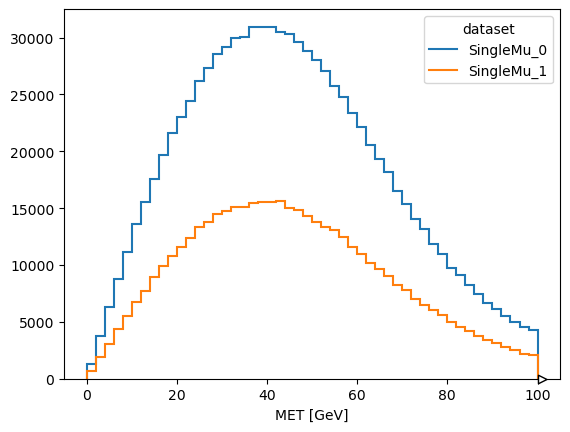

In [2]:
# run_analysis receives an executor at runtime — user shouldn't define it in the analysis code.
step_fileset  = Step(
                     name="Fileset",  
                     step_type=Fileset,   
                     builder=get_fileset,
                     builder_params={"with_failure": False},
                     output="fileset_dict"
                    )

step_analysis = Step(
                     name="Analysis", 
                     step_type=Analysis,  
                     builder=run_analysis,  
                     input="fileset_dict",    
                     output="analysis_payload"
                    )

step_plotting = Step(
                     name="Plotting", 
                     step_type=Plotting,  
                     builder=plot_results,  
                     input="analysis_payload"
                    )

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

config = RunConfig(
    strategy="by_dataset",
    percentage=20,
    cache_dir=".cache_coffea_casa",
    facility=facilities.local,
    executor_config=ExecutorConfig(executor_type="FuturesExecutor", workers=4),
)

run(workflow, config)

### If there's a failure in the pipeline

Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7f13a485b560>
  [1] Analysis -> Analysis builder=<function run_analysis at 0x7f13a485b6a0>
  [2] Plotting -> Plotting builder=<function plot_results at 0x7f13a485b9c0>
Edges:
  Fileset -> Analysis
  Analysis -> Plotting

Run config:
  Strategy:  by_dataset
  Executor:  FuturesExecutor  workers=4
  Facility:  LocalFactory  (workers=4)

Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7f13a485b560> and user parameters {'with_failure': True}
Extracted from cache: .cache_coffea_casa_failed_file/Fileset/c016b39da53c1aad6ab919396f49a19da7473f593f3e9bc9a9efa65b3fb27f4b
  -> materialized at .cache_coffea_casa_failed_file/Fileset/c016b39da53c1aad6ab919396f49a19da7473f593f3e9bc9a9efa65b3fb27f4b

Executing step 'Analysis' of type 'Analysis' with the user code <function run_analysis at 0x7f13a485b6a0> and user parameters None
Extracted from cache: .cache_coffea_casa_failed_file/Chunkin

Output()

/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1278: UserWarning: Performed attempt 1 out of 4
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1278: UserWarning: Performed attempt 2 out of 4
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1278: UserWarning: Performed attempt 3 out of 4
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1278: UserWarning: Performed attempt 4 out of 4
  warnings.warn(


loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1290, in automatic_retries
    raise e
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1276, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1360, in metadata_fetcher_root
    with uproot.open(
         ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/uproot/reading.py", line 154, in open
    file = ReadOnlyFile(
           ^^^^^^

Failure caught!
------------------------------------
Processing fileset_chunk_1.json
Extracted from cache: .cache_coffea_casa_failed_file/ChunkAnalysis/828b42b4a82b6117f8ef44a4fc1095a8da17eb420841eb85c5550765acd2b9d6
Successfully processed!
------------------------------------
Processing fileset_chunk_2.json
Extracted from cache: .cache_coffea_casa_failed_file/ChunkAnalysis/62800d4d5f08853d40d2aa3c38168f39afed79f0659358f8a2568c3abca555d8
Successfully processed!
------------------------------------
Processing fileset_chunk_3.json
Extracted from cache: .cache_coffea_casa_failed_file/ChunkAnalysis/ba947731e025243f042c969939448c4a34dfc7cbcd503fbcaad3e1eb40aa7f27
Successfully processed!
------------------------------------
Processing fileset_chunk_4.json
Extracted from cache: .cache_coffea_casa_failed_file/ChunkAnalysis/802a6e01627b6a308989046c4e8629f837d4b5559fdcf5237ffe4f283d31184a
Successfully processed!
------------------------------------
Processing fileset_chunk_5.json
Extracted from 

{'paths': {'Fileset': PosixPath('.cache_coffea_casa_failed_file/Fileset/c016b39da53c1aad6ab919396f49a19da7473f593f3e9bc9a9efa65b3fb27f4b'),
  'Analysis': PosixPath('.cache_coffea_casa_failed_file/Analysis/7178d061b59308f68d7ed126ef89dd62e7e873605e1e441df283e240d07a67ee'),
  'Plotting': PosixPath('.cache_coffea_casa_failed_file/Plotting/174f002fecccb0505f1f3b16fe6c6c7c278469d782034654d739217b6d7cf601')},
 'results': {'Fileset': {'SingleMu_0': {'files': {'root://eeeeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/R

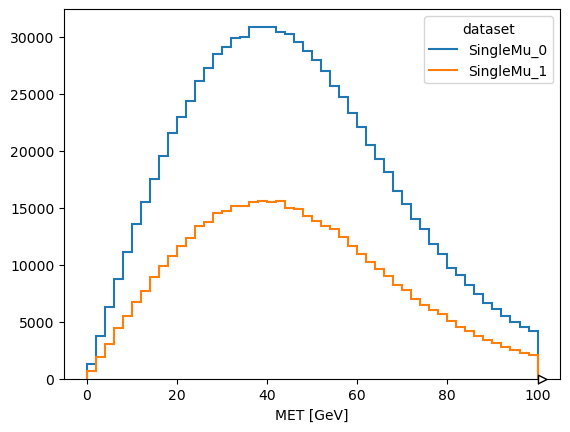

In [2]:
step_fileset  = Step(
                     name="Fileset",  
                     step_type=Fileset,   
                     builder=get_fileset,
                     builder_params={"with_failure": True},
                     output="fileset_dict"
                    )

step_analysis = Step(
                     name="Analysis", 
                     step_type=Analysis,  
                     builder=run_analysis,  
                     input="fileset_dict",    
                     output="analysis_payload"
                    )

step_plotting = Step(
                     name="Plotting", 
                     step_type=Plotting,  
                     builder=plot_results,  
                     input="analysis_payload"
                    )

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

config = RunConfig(
    strategy="by_dataset",
    percentage=20,
    cache_dir=".cache_coffea_casa_failed_file",
    facility=facilities.local,
    executor_config=ExecutorConfig(executor_type="FuturesExecutor", workers=4),
)

run(workflow, config)

### With Dask


Requires coffea-workflow and local coffea version to be uploaded to dask workers. It might stop and disable processing if adaptive scaling is used, as it will install needed additional libraries to 3 workers, but when one more is available and is assigned a job, it suddenly doesn't have a suitable environment with custom packages. That's why adaptive scaling in coffea-casa is recommended to be set up with a chosen fixed number of workers, where the number of minimum workers == number of maximum workers

Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7fe40fedeb60>
  [1] Analysis -> Analysis builder=<function run_analysis at 0x7fe40fedfc40>
  [2] Plotting -> Plotting builder=<function plot_results at 0x7fe40fee4040>
Edges:
  Fileset -> Analysis
  Analysis -> Plotting

Run config:
  Strategy:  by_dataset
  Executor:  DaskExecutor  workers=None
  Facility:  CoffeaCasaFactory

Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7fe40fedeb60> and user parameters {'with_failure': False}
Extracted from cache: .cache_coffea_casa_dask/Fileset/504db92712cfeb8906c2dc809483bddf2bdca5a1c1e4ea8f7e6d063ed09ad632
  -> materialized at .cache_coffea_casa_dask/Fileset/504db92712cfeb8906c2dc809483bddf2bdca5a1c1e4ea8f7e6d063ed09ad632

Executing step 'Analysis' of type 'Analysis' with the user code <function run_analysis at 0x7fe40fedfc40> and user parameters None
Extracted from cache: .cache_coffea_casa_dask/Analysis/69dfbed812f98211ef39d5fef9

{'paths': {'Fileset': PosixPath('.cache_coffea_casa_dask/Fileset/504db92712cfeb8906c2dc809483bddf2bdca5a1c1e4ea8f7e6d063ed09ad632'),
  'Analysis': PosixPath('.cache_coffea_casa_dask/Analysis/69dfbed812f98211ef39d5fef9dd4fb73089b60643e45aecac50ec51baf484c9'),
  'Plotting': PosixPath('.cache_coffea_casa_dask/Plotting/7d085bac0985c501c4448ae84968d9da0a163cd967eb71cc859d3dd404811f7f')},
 'results': {'Fileset': {'SingleMu_0': {'files': {'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv

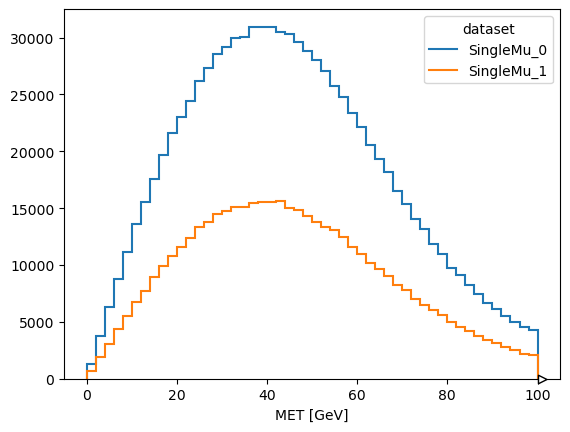

In [4]:
import sys
sys.path.insert(0, "..")

step_fileset = Step(name="Fileset", step_type=Fileset, builder=get_fileset, builder_params={"with_failure": False})
step_analysis = Step(name="Analysis", step_type=Analysis, builder=run_analysis)
step_plotting = Step(name="Plotting", step_type=Plotting, builder=plot_results)

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

# on coffea casa use fixed amount of workers if you install your custom packages
facility = facilities.CoffeaCasaFactory(
    worker_packages=("coffea>=2026.7.0",),
    worker_files=("../analysis.py",),
)
config = RunConfig(
    strategy="by_dataset",
    percentage=20,
    cache_dir=".cache_coffea_casa_dask",
    facility=facility,
    executor_config=ExecutorConfig(executor_type="DaskExecutor"),
)

run(workflow, config)

Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7f13a485b560>
  [1] Analysis -> Analysis builder=<function run_analysis at 0x7f13a485b6a0>
  [2] Plotting -> Plotting builder=<function plot_results at 0x7f13a485b9c0>
Edges:
  Fileset -> Analysis
  Analysis -> Plotting

Run config:
  Strategy:  by_dataset
  Executor:  DaskExecutor  workers=None
  Facility:  CoffeaCasaFactory

Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7f13a485b560> and user parameters {'with_failure': True}
  -> materialized at .cache_coffea_casa_dask_failed_file/Fileset/c016b39da53c1aad6ab919396f49a19da7473f593f3e9bc9a9efa65b3fb27f4b

Executing step 'Analysis' of type 'Analysis' with the user code <function run_analysis at 0x7f13a485b6a0> and user parameters None

Split strategy 'by_dataset': processing 10 fileset subsets independently...

Connecting to Dask scheduler...
Uploaded ../analysis.py to workers
Installing on workers: ['coffea>=2026.7.0']


Output()

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ /usr/local/lib/python3.12/site-packages/distributed/worker.py:2982 in _run_task_simple           │
│                                                                                                  │
│   2979 │   │   context_meter.meter("thread-cpu", func=thread_time),                              │
│   2980 │   ):                                                                                    │
│   2981 │   │   try:                                                                              │
│ ❱ 2982 │   │   │   result = task(data)                                                           │
│   2983 │   │   except (SystemExit, KeyboardInterrupt):                                           │
│   2984 │   │   │   # Special-case these, just like asyncio does all over the place. They will    │
│   2985 │   │   │   # pass through `fail_hard` and `_handle_stimulus_from_task`, and eventually   │
│                                                                                                  │
│ /usr/local/lib/python3.12/site-packages/dask/_task_spec.py:755 in __call__                       │
│                                                                                                  │
│    752 │   │   │   │   for k, kw in self.kwargs.items()                                          │
│    753 │   │   │   }                                                                             │
│    754 │   │   │   return self.func(*new_argspec, **kwargs)                                      │
│ ❱  755 │   │   return self.func(*new_argspec)                                                    │
│    756 │                                                                                         │
│    757 │   def __setstate__(self, state):                                                        │
│    758 │   │   slots = self.__class__.get_all_slots()                                            │
│                                                                                                  │
│ /usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1290 in automatic_retries   │
│                                                                                                  │
│   1287 │   │   │   │   │   if use_result_type:                                                   │
│   1288 │   │   │   │   │   │   # surface the exception instead of silently skipping              │
│   1289 │   │   │   │   │   │   # so the Runner can wrap it as Err                                │
│ ❱ 1290 │   │   │   │   │   │   raise e                                                           │
│   1291 │   │   │   │   │   warnings.warn(                                                        │
│   1292 │   │   │   │   │   │   f"Skipping bad file after {retry_count + 1} attempts. The last e  │
│   1293 │   │   │   │   │   )                                                                     │
│                                                                                                  │
│ /usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1276 in automatic_retries   │
│                                                                                                  │
│   1273 │   │   retry_count = 0                                                                   │
│   1274 │   │   while retry_count <= retries:                                                     │
│   1275 │   │   │   try:                                                                          │
│ ❱ 1276 │   │   │   │   return func(*args, **kwargs)                                              │
│   1277 │   │   │   except Exception as e:                                                        │
│   1278 │   │   │   │   warnings.warn(                                                            │
│   1279 │   │   │   │   │   f"Performed attempt {retry_count

Failure caught!
------------------------------------
Processing fileset_chunk_1.json


Preprocessing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 [ 0:00:04 < 0:00:00 | ? file/s ]

...

Processing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ 0:00:02 < 0:00:00 | 0.4 chunk/s ]

Successfully processed!
------------------------------------
Processing fileset_chunk_9.json


Preprocessing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/1 [ 0:00:03 < 0:00:00 | ? file/s ]

Processing 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [ 0:00:07 < 0:00:00 | 0.4 chunk/s ]

{'paths': {'Fileset': PosixPath('.cache_coffea_casa_dask_failed_file/Fileset/c016b39da53c1aad6ab919396f49a19da7473f593f3e9bc9a9efa65b3fb27f4b'),
  'Analysis': PosixPath('.cache_coffea_casa_dask_failed_file/Analysis/7178d061b59308f68d7ed126ef89dd62e7e873605e1e441df283e240d07a67ee'),
  'Plotting': PosixPath('.cache_coffea_casa_dask_failed_file/Plotting/174f002fecccb0505f1f3b16fe6c6c7c278469d782034654d739217b6d7cf601')},
 'results': {'Fileset': {'SingleMu_0': {'files': {'root://eeeeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events',
     'root://eospublic.cern.ch//eos/op

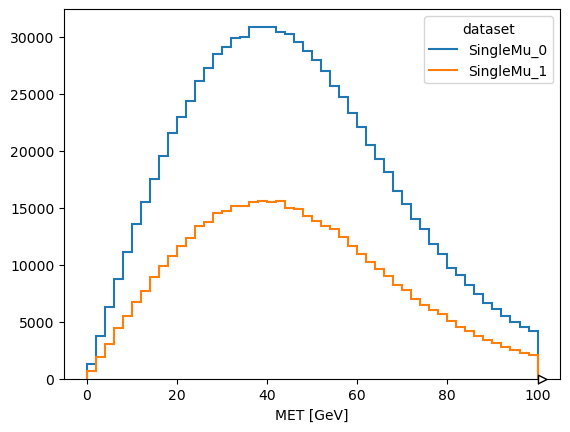

Successfully processed!
  -> materialized at .cache_coffea_casa_dask_failed_file/Analysis/7178d061b59308f68d7ed126ef89dd62e7e873605e1e441df283e240d07a67ee

Executing step 'Plotting' of type 'Plotting' with the user code <function plot_results at 0x7f13a485b9c0> and user parameters None
  -> materialized at .cache_coffea_casa_dask_failed_file/Plotting/174f002fecccb0505f1f3b16fe6c6c7c278469d782034654d739217b6d7cf601


=== Run Summary ===
  ✓  Fileset                        Fileset
  !  Analysis                       Analysis             9/10 chunks OK
       FAILED fileset_chunk_0.json: Err(OSError('XRootD error: [FATAL] Invalid address'))
  ✓  Plotting                       Plotting



In [3]:
step_fileset = Step(name="Fileset", step_type=Fileset, builder=get_fileset, builder_params={"with_failure": True})
step_analysis = Step(name="Analysis", step_type=Analysis, builder=run_analysis)
step_plotting = Step(name="Plotting", step_type=Plotting, builder=plot_results)

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

facility = facilities.CoffeaCasaFactory(
    worker_packages=("coffea>=2026.7.0",),
    worker_files=("../analysis.py",),
)
config = RunConfig(
    strategy="by_dataset",
    percentage=20,
    cache_dir=".cache_coffea_casa_dask_failed_file",
    facility=facility,
    executor_config=ExecutorConfig(executor_type="DaskExecutor"),
)

run(workflow, config)